In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [2]:
wd = 0.642570281124498
wm = 1.0
tau = 500
tlist = np.linspace(0, tau, 1000)
detuning = 0.2
dlist = np.linspace(0, 4, 41)
N = 8
np.random.seed(0)

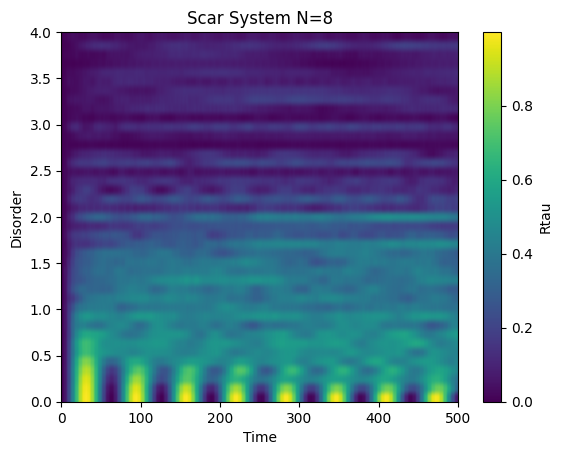

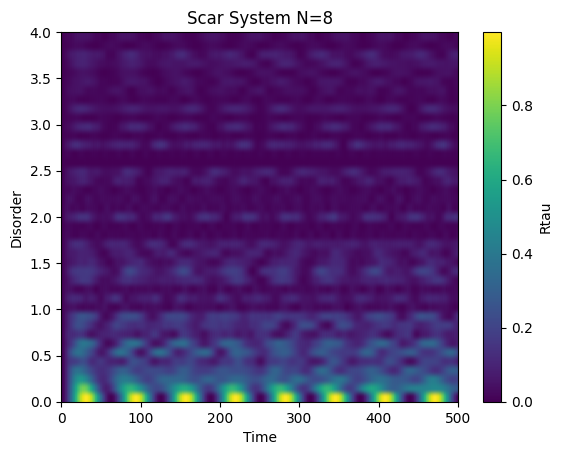

In [ ]:
expectationDensityEtau = []
H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
basisLen = len(basisList)

for d in dlist:
    # random diagonal with zero mean
    diag_vals = np.random.uniform(-d, d, basisLen)
    diag_vals -= np.mean(diag_vals)
    diagLocation = list(range(basisLen))
    H_anharm = csr_matrix((diag_vals, (diagLocation, diagLocation)), shape=(basisLen, basisLen))
    H_anharm = qt.Qobj(H_anharm)

    Hscar = H0 + H_anharm
    deigvals, deigstates = Hscar.eigenstates()
    band = deigvals[-1] - deigvals[0]

    args = {"A": 0.1, "omega": wd}
    H = qt.QobjEvo([Hscar, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, deigstates[0], tlist)

    # eq 2.3
    temp = []
    H00 = psi_t.states[0].dag() * Hscar * psi_t.states[0]
    for states in psi_t.states:
        H0tau = states.dag() * Hscar * states
        Etau = H0tau - H00
        temp.append(Etau.real)
    temp = np.array(temp)
    expectationDensityEtau.append(temp / band)

# eq 4.1
plt.imshow(expectationDensityEtau,
           extent=[tlist.min(), tlist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Rtau")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder")
plt.xlabel("Time")
plt.show()

# decoupled system
expectationDensityEtau = []
qlen = 2**N

for d in dlist:
    qH0, qH1, wm = get_random_qubit_ham(N, detuning=d, wm=wm)
    qeigvals, qeigstates = qH0.eigenstates()
    qband = qeigvals[-1] - qeigvals[0]

    qargs = {"A": 0.1, "omega": wm}
    qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigstates[0], tlist)

    # eq 2.3
    temp = []
    H00 = qpsi_t.states[0].dag() * qH0 * qpsi_t.states[0]
    for states in qpsi_t.states:
        H0tau = states.dag() * qH0 * states
        Etau = H0tau - H00
        temp.append(Etau.real)
    temp = np.array(temp)
    expectationDensityEtau.append(temp / qband)

# eq 4.1
plt.imshow(expectationDensityEtau,
           extent=[tlist.min(), tlist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Rtau")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder")
plt.xlabel("Time")
plt.show()

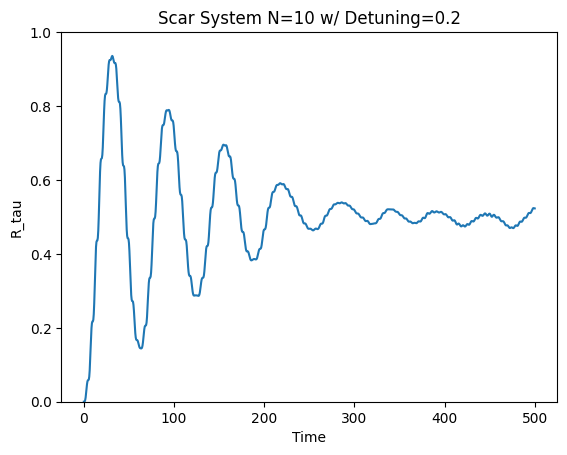

In [5]:
# scar system
args = {"A": 0.1, "omega": wd, "limit": 31}
H0, H1, eigenvalues, eigenstates, psi0, basisList = get_random_scar_ham(N, detuning=detuning)
H = qt.QobjEvo([H0, [H1, coeff]], args=args)
psi_t = qt.sesolve(H, eigenstates[0], tlist)

# eq 2.3
expectationEtau = []
H00 = psi_t.states[0].dag() * H0 * psi_t.states[0]
for states in psi_t.states:
    H0tau = states.dag() * H0 * states
    Etau = H0tau - H00
    expectationEtau.append(Etau.real)
expectationEtau = np.array(expectationEtau)

# bandwidth
band = eigenvalues[-1] - eigenvalues[0]

# eq 4.1
Rtau = expectationEtau / band
plt.title(f"Scar System N={N} w/ Detuning={detuning}")
# plt.xscale("log")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.plot(tlist, Rtau)
plt.show()

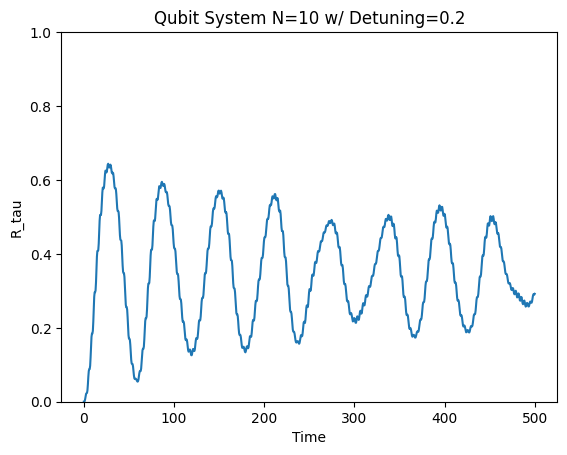

In [4]:
# non interacting qubit
qH0, qH1, qwq = get_random_qubit_ham(N, detuning=detuning)
qargs = {"A": 0.1, "omega": qwq}
qpsi0 = qt.tensor([qt.basis(2,0)]*N)
qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
qpsi_t = qt.sesolve(qH, qpsi0, tlist)

# eq 2.3
qexpectationEtau = []
qH00 = qpsi_t.states[0].dag() * qH0 * qpsi_t.states[0]
for qstates in qpsi_t.states:
    qH0tau = qstates.dag() * qH0 * qstates
    qEtau = qH0tau - qH00
    qexpectationEtau.append(qEtau.real)
qexpectationEtau = np.array(qexpectationEtau)

# bandwidth
qevals, qestates = qH0.eigenstates()
qband = qevals[-1] - qevals[0]

# eq 4.1
qRtau = qexpectationEtau / qband
plt.title(f"Qubit System N={N} w/ Detuning={detuning}")
# plt.xscale("log")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.plot(tlist, qRtau)
plt.show()

In [21]:
# eq 2.5
expectationEbar = []
for states in psi_t.states:
    expectationEbar.append(states.dag() * H0 * states)
integral = np.trapezoid(tlist, expectationEbar)
E_bar = integral / tau

In [22]:
# ergotropy calculation
def trace(mat):
    basisLen = len(basisList)
    toBeSummed = [qt.basis(basisLen, i).dag() * mat * qt.basis(basisLen, i) for i in range(basisLen)]
    return sum(toBeSummed)

ergoList = []
passiveErgo = trace(psi0 * psi0.dag() * H0)
for states in psi_t.states:
    densityMat = states * states.dag()
    innerTrace = densityMat * H0
    ergoList.append(trace(innerTrace) - passiveErgo)

plt.plot(tlist, ergoList)
plt.ylabel("Ergotropy")
plt.xlabel("Time")
plt.show()

KeyboardInterrupt: 